In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb

import shap
import warnings
warnings.filterwarnings('ignore')

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_csv('dont-overfit-ii/train.csv')
test = pd.read_csv('dont-overfit-ii/test.csv')

labels = train.columns.drop(['id', 'target'])
target = train['target']

In [3]:
print('Train rows:', train.shape[0])
print('Test rows:', test.shape[0])
print('Data columns:', test.columns.drop(['id']).shape[0])

Train rows: 250
Test rows: 19750
Data columns: 300


In [4]:
target.value_counts()

target
0.0    183
1.0     67
Name: count, dtype: int64

Все данные распределны по Гаусову закону (видно по гистограммам с kaggl)

Поэтому Скейлер можем не применять

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    train[labels], target, test_size=0.2, random_state=42, stratify=target
)

In [6]:
lasso_lr = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lasso_lr.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [7]:
non_zeros_coef = np.sum(lasso_lr.coef_ != 0)
important_features_l1 = np.where(lasso_lr.coef_[0] != 0)[0]

print(f'Важные признаки через Lasso: {important_features_l1}')

Важные признаки через Lasso: [ 16  18  32  59  66  74 101 107 113 126 127 135 136 140 144 163 176 199
 200 211 213]


In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
importances = rf.feature_importances_
indices_rf = np.argsort(importances)[::-1][:30]

print(f'Важные признаки через RF: {indices_rf}')

Важные признаки через RF: [ 18 220 176  29  66 106 103  59 127 299 219 262  52 241  32 162  56  93
 284 289  16 213 126 211 280 100 214 163 205 272]


In [10]:
selected_features = np.union1d(important_features_l1, indices_rf)

In [11]:
print(f'Признаки для обучения: {selected_features}')
print(f'Кол-во признаков: {len(selected_features)}')

Признаки для обучения: [ 16  18  29  32  52  56  59  66  74  93 100 101 103 106 107 113 126 127
 135 136 140 144 162 163 176 199 200 205 211 213 214 219 220 241 262 272
 280 284 289 299]
Кол-во признаков: 40


In [12]:
X_train_selected = X_train.loc[:, selected_features.astype(str)]
X_val_selected = X_val.loc[:, selected_features.astype(str)]
X_test_selected = test.loc[:, selected_features.astype(str)]

In [13]:
X_train_selected.head()

,16,18,29,32,52,56,59,66,74,93,...,214,219,220,241,262,272,280,284,289,299
239,0.670,-0.370,0.984,-1.483,-0.186,0.473,-1.693,-0.660,1.494,0.414,...,-0.705,-0.733,-1.185,0.711,0.195,0.366,-0.144,-0.833,-0.033,-0.861
207,0.198,-0.519,-1.041,-1.090,2.379,-1.574,1.766,-0.154,0.918,-0.203,...,0.379,-0.549,1.441,0.404,0.955,-1.043,0.305,1.686,0.612,1.479
192,0.401,0.588,0.894,0.608,0.590,2.223,-0.451,-1.324,-0.845,0.431,...,-1.428,0.820,-0.703,-1.224,1.019,-1.541,0.108,-0.425,0.560,-1.061
50,-0.533,-0.018,-0.244,1.027,-0.103,-0.525,0.462,-0.423,-0.623,-0.741,...,0.999,1.045,0.864,-0.020,-1.133,0.250,-0.025,0.571,0.040,-0.237
14,-0.856,-0.790,-0.551,0.699,-0.447,-1.619,-0.377,-0.184,-0.174,-0.823,...,-1.134,-1.832,-1.237,0.675,-1.487,1.227,-0.289,-0.512,0.024,-0.371


In [14]:
smote = SMOTE(random_state=42)

In [15]:
print(f"Размер данных до SMOTE: {X_train_selected.shape}")

Размер данных до SMOTE: (200, 40)


In [16]:
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

In [17]:
print(f"Размер данных после SMOTE: {X_train_smote.shape}")

Размер данных после SMOTE: (292, 40)


In [18]:
y_train_smote.value_counts()

target
0.0    146
1.0    146
Name: count, dtype: int64

In [19]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name=None):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    train_f1 = f1_score(y_train, y_train_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    if hasattr(model, 'predict_proba'):
        y_val_proba = model.predict_proba(X_val)[:, 1]
        val_roc_auc = roc_auc_score(y_val, y_val_proba)
    else:
        val_roc_auc = None

    print(f"\n{model_name}:")
    print(f"  Train Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")
    print(f"  Train F1-score: {train_f1:.4f}, Validation F1-score: {val_f1:.4f}")

    if val_roc_auc:
        print(f"  Validation ROC-AUC: {val_roc_auc:.4f}")

    return model, val_acc, val_f1

In [20]:
baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr, baseline_acc, baseline_f1 = evaluate_model(
    baseline_lr, 
    X_train, y_train, 
    X_val, y_val, 
    'LogReg (без регуляризации + все данные)'
)


LogReg (без регуляризации + все данные):
  Train Accuracy: 1.0000, Validation Accuracy: 0.7600
  Train F1-score: 1.0000, Validation F1-score: 0.3333
  Validation ROC-AUC: 0.7713


In [21]:
l2_lr = LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=42)
l2_lr, l2_lr_acc, l2_lr_f1 = evaluate_model(
    l2_lr, 
    X_train_selected, y_train,
    X_val_selected, y_val, 
    'LogReg (L2 + smote + selected features)'
)


LogReg (L2 + smote + selected features):
  Train Accuracy: 0.9300, Validation Accuracy: 0.7400
  Train F1-score: 0.8542, Validation F1-score: 0.3158
  Validation ROC-AUC: 0.7734


In [22]:
l2_lr_smote = LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=42)
l2_lr_smote, l2_lr_smote_acc, l2_lr_smote_f1 = evaluate_model(
    l2_lr_smote,
    X_train_smote, y_train_smote, 
    X_val_selected, y_val, 
    'LogReg (L2 + smote + selected features)'
)


LogReg (L2 + smote + selected features):
  Train Accuracy: 0.9452, Validation Accuracy: 0.7200
  Train F1-score: 0.9463, Validation F1-score: 0.3636
  Validation ROC-AUC: 0.7755


In [23]:
svm_model = SVC(kernel='linear', C=0.1, probability=True, random_state=42)
svm_model, svm_acc, svm_f1 = evaluate_model(
    svm_model, 
    X_train_selected, y_train, 
    X_val_selected, y_val, 
    'SVM (линейное ядро)'
)


SVM (линейное ядро):
  Train Accuracy: 0.9450, Validation Accuracy: 0.7600
  Train F1-score: 0.8889, Validation F1-score: 0.4000
  Validation ROC-AUC: 0.7318


In [24]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model, xgb_acc, xgb_f1 = evaluate_model(
    xgb_model, 
    X_train_selected, y_train, 
    X_val_selected, y_val, 
    "XGBoost"
)


XGBoost:
  Train Accuracy: 1.0000, Validation Accuracy: 0.7000
  Train F1-score: 1.0000, Validation F1-score: 0.2105
  Validation ROC-AUC: 0.7089


In [25]:
def evaluate_val(model, X_val, y_val, model_name=None):
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    if hasattr(model, 'predict_proba'):
        y_val_proba = model.predict_proba(X_val)[:, 1]
        val_roc_auc = roc_auc_score(y_val, y_val_proba)
    else:
        val_roc_auc = None

    print(f"\n{model_name}:")
    print(f"  Validation Accuracy: {val_acc:.4f}")
    print(f"  Validation F1-score: {val_f1:.4f}")

    if val_roc_auc:
        print(f"  Validation ROC-AUC: {val_roc_auc:.4f}")

    print('\n')
    print(classification_report(y_val, y_val_pred))


In [26]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'lbfgs'],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'max_iter': [500, 1000, 1500]
}

In [27]:
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)

In [28]:
grid_lr.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_lr.best_params_}")
print(f"Лучший F1-score на кросс-валидации: {grid_lr.best_score_:.4f}")

Лучшие параметры: {'C': 100, 'l1_ratio': 0.1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
Лучший F1-score на кросс-валидации: 0.3731


In [29]:
grid_lr.fit(X_train_selected, y_train)
print(f"Лучшие параметры: {grid_lr.best_params_}")
print(f"Лучший F1-score на кросс-валидации: {grid_lr.best_score_:.4f}")

Лучшие параметры: {'C': 1, 'l1_ratio': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший F1-score на кросс-валидации: 0.7014


In [30]:
grid_lr.fit(X_train_smote, y_train_smote)
print(f"Лучшие параметры: {grid_lr.best_params_}")
print(f"Лучший F1-score на кросс-валидации: {grid_lr.best_score_:.4f}")

Лучшие параметры: {'C': 1, 'l1_ratio': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Лучший F1-score на кросс-валидации: 0.9054


In [31]:
best_lr_grid = grid_lr.best_estimator_

In [32]:
param_dist_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'max_iter': [500, 1000, 1500]
}

random_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_dist_lr,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

In [33]:
random_lr.fit(X_train_smote, y_train_smote)

,estimator,LogisticRegre...ndom_state=42)
,param_distributions,"{'C': [0.001, 0.01, ...], 'l1_ratio': [0.1, 0.3, ...], 'max_iter': [500, 1000, ...], 'penalty': ['l1', 'l2'], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [34]:
best_lr_rand =  random_lr.best_estimator_

In [35]:
evaluate_val(best_lr_grid, X_val_selected, y_val, model_name='Логистическая Регрессия Дискретный перебор')
evaluate_val(best_lr_rand, X_val_selected, y_val, model_name='Логистическая Регрессия Непрерывный перебор')


Логистическая Регрессия Дискретный перебор:
  Validation Accuracy: 0.7600
  Validation F1-score: 0.5000
  Validation ROC-AUC: 0.8108


              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84        37
         1.0       0.55      0.46      0.50        13

    accuracy                           0.76        50
   macro avg       0.68      0.66      0.67        50
weighted avg       0.75      0.76      0.75        50


Логистическая Регрессия Непрерывный перебор:
  Validation Accuracy: 0.7600
  Validation F1-score: 0.5000
  Validation ROC-AUC: 0.8108


              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84        37
         1.0       0.55      0.46      0.50        13

    accuracy                           0.76        50
   macro avg       0.68      0.66      0.67        50
weighted avg       0.75      0.76      0.75        50



In [36]:
param_dist_xgb = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'base_score': [0.5]
}

random_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_dist_xgb,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_xgb.fit(X_train_smote, y_train_smote)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'base_score': [0.5], 'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [37]:
best_xgb = random_xgb.best_estimator_

In [38]:
evaluate_val(best_xgb, X_val_selected, y_val, model_name='XGB на RandomSearch')


XGB на RandomSearch:
  Validation Accuracy: 0.7800
  Validation F1-score: 0.4762
  Validation ROC-AUC: 0.7672


              precision    recall  f1-score   support

         0.0       0.81      0.92      0.86        37
         1.0       0.62      0.38      0.48        13

    accuracy                           0.78        50
   macro avg       0.72      0.65      0.67        50
weighted avg       0.76      0.78      0.76        50



In [39]:
best_xgb

,objective,'binary:logistic'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


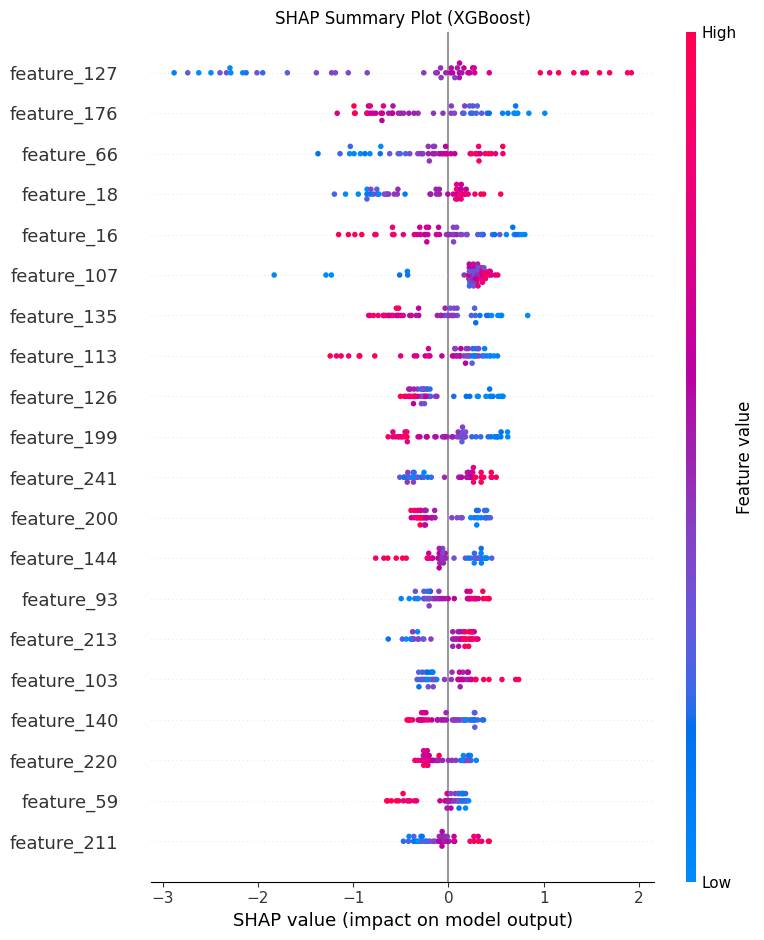

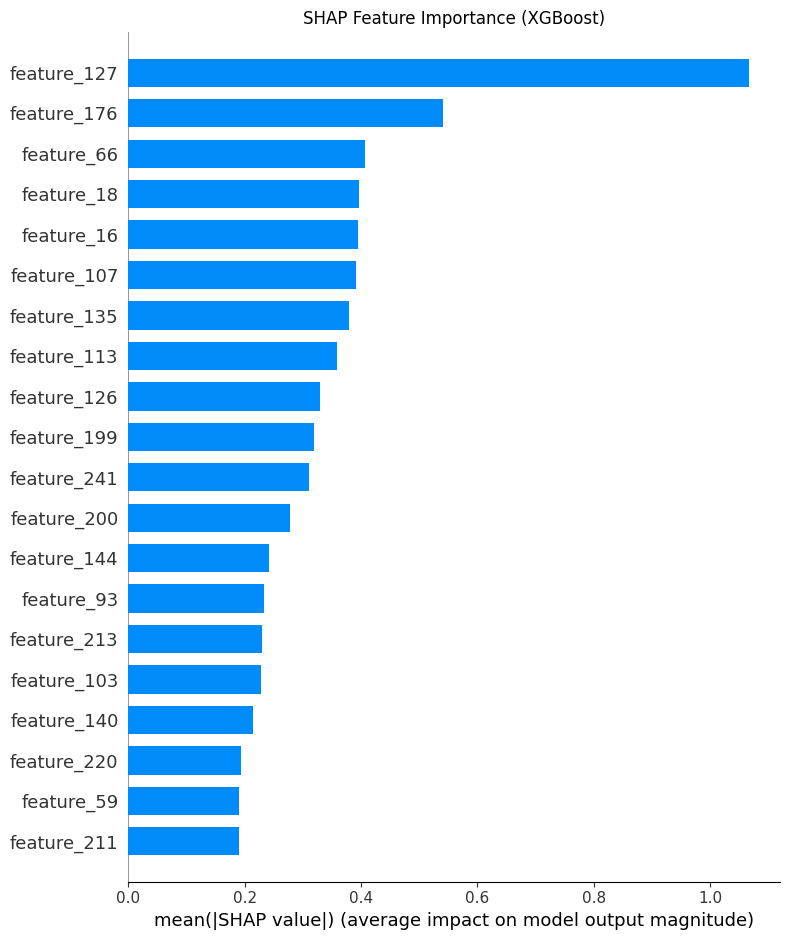

In [42]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_val_selected)


plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_selected, 
                    feature_names=[f'feature_{i}' for i in selected_features],
                    show=False)
plt.title('SHAP Summary Plot (XGBoost)')
plt.tight_layout()
plt.show()

# Бар-плот важности признаков
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_selected, plot_type="bar",
                    feature_names=[f'feature_{i}' for i in selected_features],
                    show=False)
plt.title('SHAP Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

In [48]:
test['pred_xgb'] = best_xgb.predict(X_test_selected)
test['pred_lr'] = best_lr_rand.predict(X_test_selected)

In [97]:
test['pred_proba_xgb'] = best_xgb.predict_proba(X_test_selected)[:, 0]

In [51]:
test['pred_xgb'] = test['pred_xgb'].astype(int)
test['pred_lr'] = test['pred_lr'].astype(int)

In [52]:
test.loc[:, ['id', 'pred_xgb', 'pred_lr']]

,id,pred_xgb,pred_lr
0,250,1,1
1,251,0,0
2,252,0,0
3,253,0,0
4,254,1,1
...,...,...,...
19745,19995,1,0
19746,19996,1,1
19747,19997,0,0
19748,19998,0,0


In [56]:
test.loc[:, ['id', 'pred_xgb']].rename(columns={'pred_xgb': 'target'}).to_csv('xgb_pred.csv', index=False)
test.loc[:, ['id', 'pred_lr']].rename(columns={'pred_lr': 'target'}).to_csv('lr_pred.csv', index=False)

In [99]:
test.loc[:, ['id', 'pred_proba_xgb']].rename(columns={'pred_proba_xgb': 'target'}).to_csv('xgb_proba_pred.csv', index=False)

https://www.kaggle.com/competitions/dont-overfit-ii/submissions

- xgb: 0.512
- lr:  0.497 

In [57]:
X = train[labels]
y = target

In [58]:
y.value_counts()

target
0.0    183
1.0     67
Name: count, dtype: int64

In [69]:
X = X.loc[:, selected_features.astype(str)]

In [59]:
smote_2 = SMOTE(random_state=42)

In [70]:
X_smote, y_smote = smote_2.fit_resample(X,y)

In [71]:
y_smote.value_counts()

target
1.0    183
0.0    183
Name: count, dtype: int64

In [86]:
param_dist_xgb = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'base_score': [0.7]
}

random_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_dist_xgb,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_smote, y_smote)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'base_score': [0.7], 'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [88]:
xgb_3 = random_xgb.best_estimator_

In [ ]:
test['xgb_3'] = xgb_3.predict(X_test_selected)

In [104]:
pred_cols = ['pred_lr', 'pred_xgb', 'xgb_1', 'xgb_2', 'xgb_3', 'lr_all']

for col in pred_cols:
    print(test[col].value_counts())

pred_lr
0    13582
1     6168
Name: count, dtype: int64
pred_xgb
0    14557
1     5193
Name: count, dtype: int64
xgb_1
0    15336
1     4414
Name: count, dtype: int64
xgb_2
0    14216
1     5534
Name: count, dtype: int64
xgb_3
0    14113
1     5637
Name: count, dtype: int64
lr_all
0.0    13220
1.0     6530
Name: count, dtype: int64


In [91]:
test.loc[:, ['id', 'xgb_3']].rename(columns={'xgb_3': 'target'}).to_csv('xgb_3_all_pred.csv', index=False)

In [100]:
param_dist_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'max_iter': [500, 1000, 1500]
}

random_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_dist_lr,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_lr.fit(X_smote, y_smote)

,estimator,LogisticRegre...ndom_state=42)
,param_distributions,"{'C': [0.001, 0.01, ...], 'l1_ratio': [0.1, 0.3, ...], 'max_iter': [500, 1000, ...], 'penalty': ['l1', 'l2'], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [102]:
lr_all = random_lr.best_estimator_

In [103]:
test['lr_all'] = lr_all.predict(X_test_selected)

In [105]:
test.loc[:, ['id', 'lr_all']].rename(columns={'lr_all': 'target'}).to_csv('lr_all_pred.csv', index=False)